# **Extended Data Figure 4**
Reproduces Extended Data Figure 4 by running leaky integrate-and-fire version of the isolated mini circuit.

In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

from src.utils.sim_utils import run_LIF_network
from src.utils.plot_utils import *

Using diffeqsolve-based neural simulation (original)


In [2]:
# # PLOT defaults
plt.rcParams["font.sans-serif"] = "Arial"
plt.rcParams["axes.spines.right"] = "False"
plt.rcParams["axes.spines.top"] = "False"
plt.rcParams["svg.fonttype"] = "none"
plt.rcParams["figure.figsize"] = (2,2)
plt.rcParams['axes.linewidth'] = 0.25
plt.rcParams["xtick.major.size"] = 1.7
plt.rcParams["xtick.minor.size"] = 1.0
plt.rcParams["ytick.major.size"] = 1.7
plt.rcParams["xtick.major.width"] = 0.25
plt.rcParams["xtick.minor.width"] = 0.18
plt.rcParams["ytick.major.width"] = 0.25
plt.rcParams["figure.dpi"] = 200

plt.rcParams["axes.labelpad"] = 1.5
plt.rcParams["xtick.major.pad"] = 1.5
plt.rcParams["ytick.major.pad"] = 1.5

SMALL_SIZE = 6
LABEL_SIZE = 7
AXLABEL_SIZE = 8
TITLE_SIZE = 10

plt.rcParams["font.family"] = "Arial" # "Arial"
plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=TITLE_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=AXLABEL_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=LABEL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=TITLE_SIZE)  # fontsize of the figure title

plt.rcParams["axes.labelpad"] = 1.5
plt.rcParams["xtick.major.pad"] = 1.5
plt.rcParams["ytick.major.pad"] = 1.5

moduleColors = get_module_colors()

dnColor = "#51bbad"
excColor = "#d84a2e"
inhColor = "#026b85"
mnColor = "#267655"

lightDnColor = "#a7dcd5ff"
lightExcColor = "#ff9985"
lightInhColor = "#00acd6"
connColormap = sns.blend_palette([inhColor,lightInhColor,"white",lightExcColor,excColor],as_cmap=True)

In [3]:
keep_spiking_only = True
# keep_spiking_only = False

weights_minicircuit = np.load("../data/manc t1l minicircuit/W_20241118_T1Lminicircuit.npy")
table_minicircuit = pd.read_csv("../data/manc t1l minicircuit/wTable_20241118_T1Lminicircuit.csv")
minicircuit_size = (table_minicircuit["class"] != "motor neuron").sum()

if keep_spiking_only:
    keep_bodyIDs = [10093, 10707, 11751, 13905, 12686]
    keep = table_minicircuit["bodyId"].apply(lambda x: x in keep_bodyIDs)
else:
    send_connections = (weights_minicircuit[np.arange(minicircuit_size)] != 0).any(0)
    receive_connections = (weights_minicircuit[:, np.arange(minicircuit_size)] != 0).any(1)
    keep = send_connections | receive_connections

weights_minicircuit = weights_minicircuit[keep][:, keep]
table_minicircuit = table_minicircuit[keep]
weights_minicircuit[table_minicircuit["class"] == "motor neuron"] = 0

network_size = keep.sum()
network_input = np.zeros(keep.sum())
network_input[table_minicircuit["class"] == "descending neuron"] = 1

network_weights = weights_minicircuit.T

In [4]:
def default_params() -> dict:
    params = {}

    params["V_rest"] = -52e-3  # [V]
    params["V_reset"] = -52e-3  # [V]
    params["V_thresh"] = -45e-3  # [V]
    params["t_refractory"] = 2.2e-3  # [s]
    params["tau_membrane"] = 20e-3  # [s]
    params["tau_synaptic"] = 5e-3  # [s]
    params["w_synaptic"] = 0.275e-3  # [V]
    params["t_delay"] = 1.8e-3  # [s]
    params["membrane_conductance"] = 10e-9  # [S]
    params["V_init"] = -52e-3  # [V]
    params["dt"] = 1e-5  # [s]
    params["simulation_time"] = 0.3  # [s]
    params["network_input"] = 0.15e-9  # [A]
    params["network_size"] = network_size
    params["network_weights"] = network_weights
    return params


params = default_params()

In [5]:
history_V, history_spikes = run_LIF_network(params, network_input)
figFolder = "../figures/lif-figures"

/home/smpuglie/vnc-connectome-sim/src/utils/plot_utils.py:356: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax[0].scatter(


(np.float64(-70.0), np.float64(-40.0))

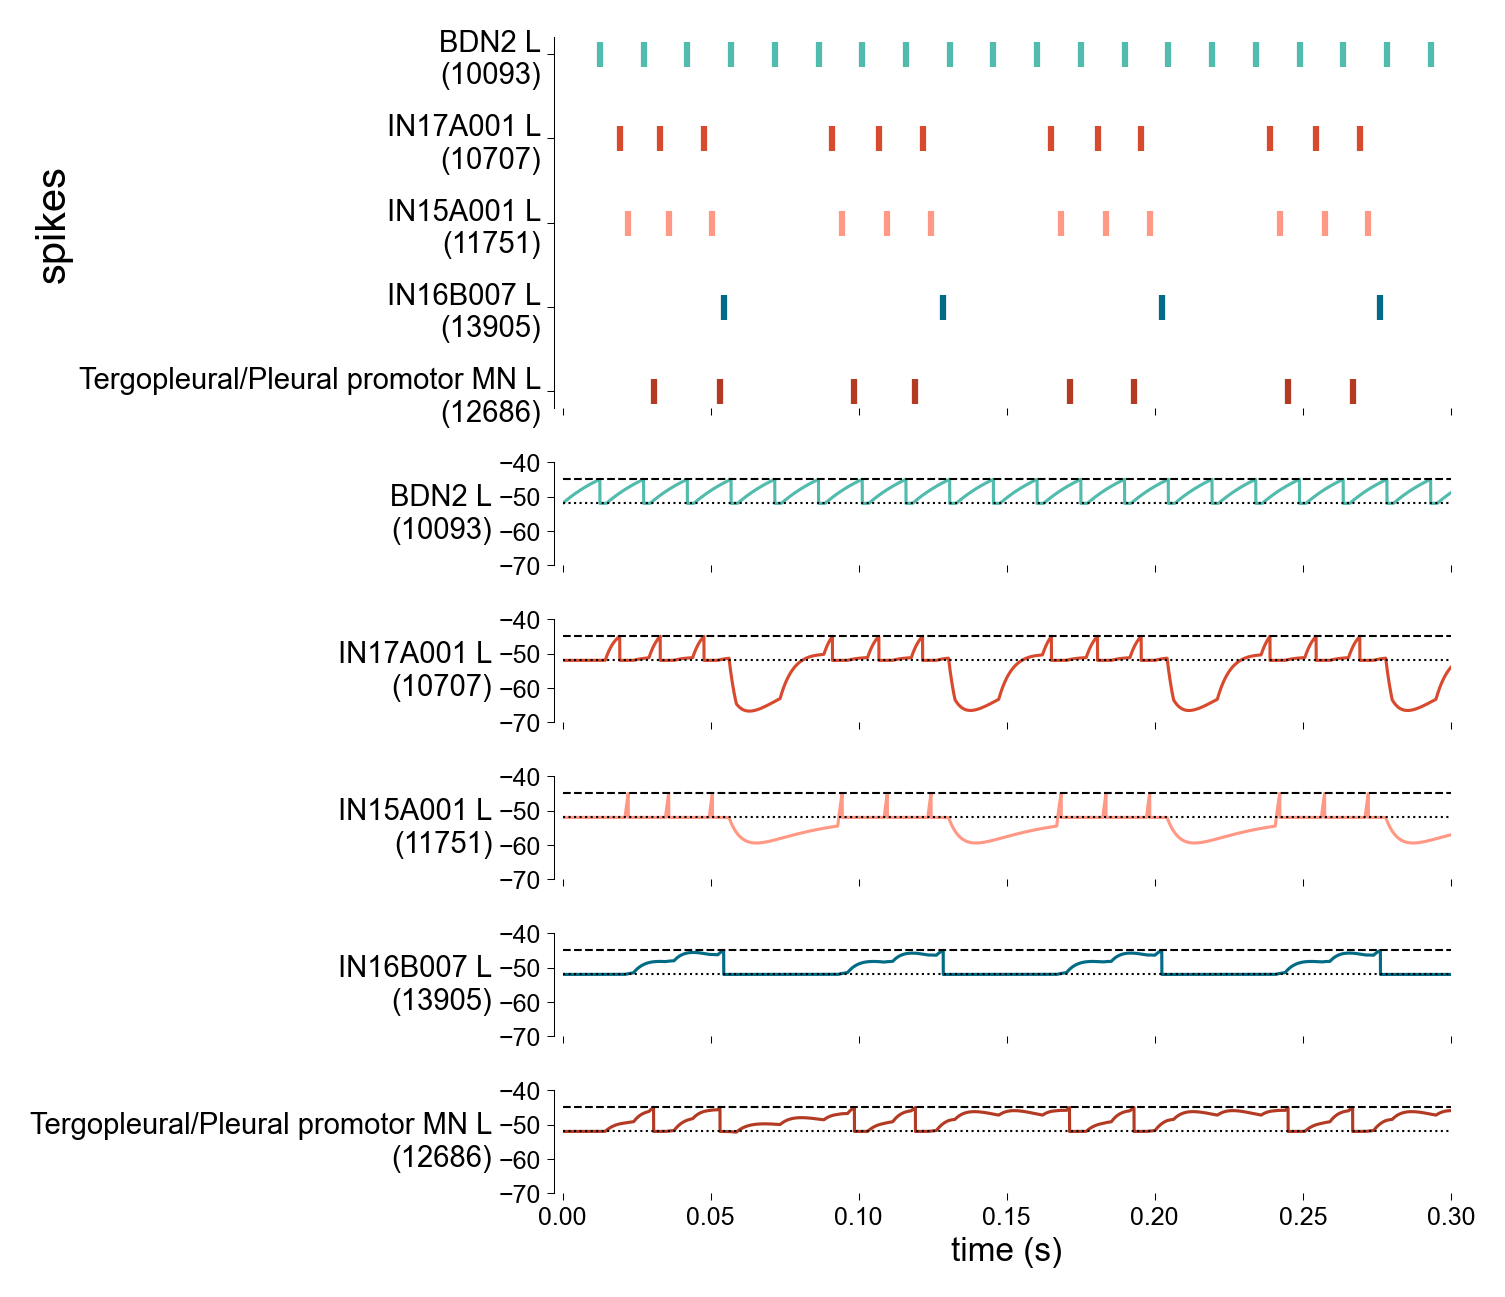

In [6]:
fig, ax = plot_lif_spikes(
    spike_activity=history_spikes,
    membrane_potential=history_V,
    duration=params["simulation_time"],
    dt=params["dt"],
    neuron_labels=list(table_minicircuit.apply(lambda x: f"{x['type']} {x['somaSide'][0]}\n({x['bodyId']})",axis=1)),
                                            #    {x['bodyId']}--{x['type']}", axis=1)),
    spike_marker_size=36,
    spike_figure_height=1.8,
    membrane_potential_figure_height = 0.5,
    y_label_rotation=0,
    palette = sns.color_palette([dnColor,excColor,lightExcColor,inhColor,moduleColors["coxa swing"]]),
    # palette = sns.color_palette("husl",history_V.shape[1]),
    show_plot=False,
)

display(ax[-1].get_ylim())

plt.tight_layout()
fig.set_dpi(300)


# if not os.path.exists(figFolder):
#     os.makedirs(figFolder)
# if keep_spiking_only:
#     plt.savefig(figFolder+"/LIF-model-spiking-only.svg", bbox_inches="tight", transparent=True)
# else:
#     plt.savefig(figFolder+"/LIF-model-all.svg", bbox_inches="tight", transparent=True)

plt.show()